In [ ]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

Melhor Rota (A*): Arad -> Sibiu -> Rimnicu Vilcea -> Pitesti -> Bucharest
Custo Total: 418 km


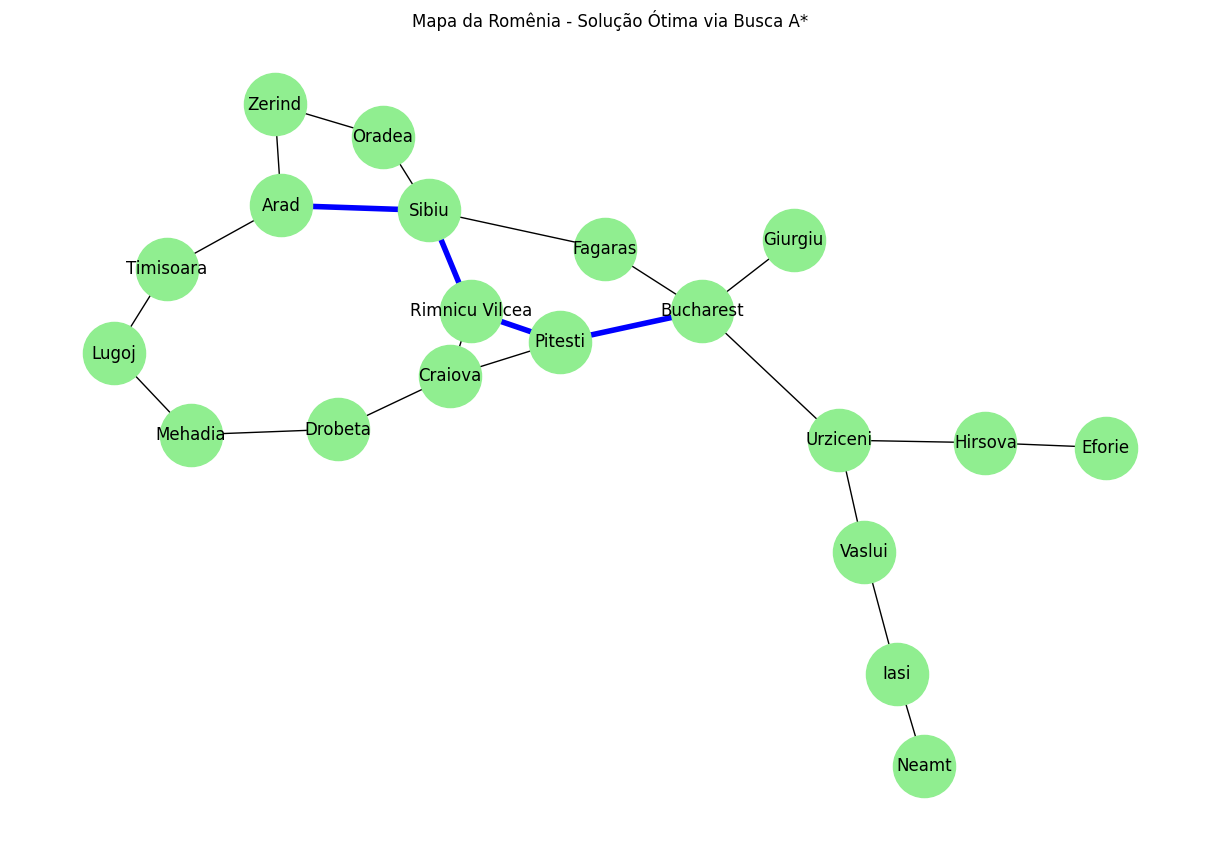

In [ ]:


# 1. Grafo da Romênia (Distâncias reais entre cidades)
romenia = {
    'Arad': {'Zerind': 75, 'Sibiu': 140, 'Timisoara': 118},
    'Zerind': {'Arad': 75, 'Oradea': 71},
    'Oradea': {'Zerind': 71, 'Sibiu': 151},
    'Sibiu': {'Arad': 140, 'Oradea': 151, 'Fagaras': 99, 'Rimnicu Vilcea': 80},
    'Timisoara': {'Arad': 118, 'Lugoj': 111},
    'Lugoj': {'Timisoara': 111, 'Mehadia': 70},
    'Mehadia': {'Lugoj': 70, 'Drobeta': 75},
    'Drobeta': {'Mehadia': 75, 'Craiova': 120},
    'Craiova': {'Drobeta': 120, 'Rimnicu Vilcea': 146, 'Pitesti': 138},
    'Rimnicu Vilcea': {'Sibiu': 80, 'Craiova': 146, 'Pitesti': 97},
    'Fagaras': {'Sibiu': 99, 'Bucharest': 211},
    'Pitesti': {'Rimnicu Vilcea': 97, 'Craiova': 138, 'Bucharest': 101},
    'Bucharest': {'Fagaras': 211, 'Pitesti': 101, 'Giurgiu': 90, 'Urziceni': 85},
    'Giurgiu': {'Bucharest': 90},
    'Urziceni': {'Bucharest': 85, 'Vaslui': 142, 'Hirsova': 98},
    'Hirsova': {'Urziceni': 98, 'Eforie': 86},
    'Eforie': {'Hirsova': 86},
    'Vaslui': {'Urziceni': 142, 'Iasi': 92},
    'Iasi': {'Vaslui': 92, 'Neamt': 87},
    'Neamt': {'Iasi': 87}
}

# 2. Heurística (h): Distância em linha reta até Bucharest
# Dados clássicos do livro de IA do Russell/Norvig
distancia_linha_reta_bucharest = {
    'Arad': 366, 'Bucharest': 0, 'Craiova': 160, 'Drobeta': 242, 'Eforie': 161,
    'Fagaras': 176, 'Giurgiu': 77, 'Hirsova': 151, 'Iasi': 226, 'Lugoj': 244,
    'Mehadia': 241, 'Neamt': 234, 'Oradea': 380, 'Pitesti': 100, 'Rimnicu Vilcea': 193,
    'Sibiu': 253, 'Timisoara': 329, 'Urziceni': 80, 'Vaslui': 199, 'Zerind': 374
}

def a_estrela(grafo, inicio, objetivo):
    # Fila de prioridade: (f_score, cidade_atual, caminho, custo_g)
    fronteira = [(distancia_linha_reta_bucharest[inicio], inicio, [inicio], 0)]
    visitados = set()

    while fronteira:
        (f, atual, caminho, g) = heapq.heappop(fronteira)

        if atual == objetivo:
            return caminho, g

        if atual not in visitados:
            visitados.add(atual)
            for vizinho, distancia in grafo[atual].items():
                if vizinho not in visitados:
                    novo_g = g + distancia
                    novo_f = novo_g + distancia_linha_reta_bucharest[vizinho]
                    heapq.heappush(fronteira, (novo_f, vizinho, caminho + [vizinho], novo_g))
    return None

# 3. Execução
rota, custo = a_estrela(romenia, 'Arad', 'Bucharest')

print(f"Melhor Rota (A*): {' -> '.join(rota)}")
print(f"Custo Total: {custo} km")

# 4. Visualização
G = nx.Graph()
for cidade, vizinhos in romenia.items():
    for v, d in vizinhos.items(): G.add_edge(cidade, v, weight=d)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightgreen', node_size=2000)
path_edges = list(zip(rota, rota[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='blue', width=4)
plt.title("Mapa da Romênia - Solução Ótima via Busca A*")
plt.show()